In [1]:
from torch.utils.data import DataLoader
from flytracker.io import VideoDataset
from flytracker.preprocessing import preprocessing
import numpy as np
import matplotlib.pyplot as plt
from flytracker import run
from flytracker.analysis import annotate

# Making mask

In [2]:
movie_path = "videos/seq_1.mp4"
mapping_folder = "../../distortion_maps/"

In [3]:
# Making mask
mask = np.ones((1080, 1280), dtype=bool)
mask[:170, :] = 0
mask[-155:, :] = 0
mask[:, :240] = 0
mask[:, -275:] = 0

In [14]:
dataset = VideoDataset(movie_path, preprocessing, mask, mapping_folder)
loader = DataLoader(dataset, batch_size=1, pin_memory=True)

In [9]:
dataset.set_frame(100)

In [10]:
image = next(enumerate(loader))[1].squeeze()

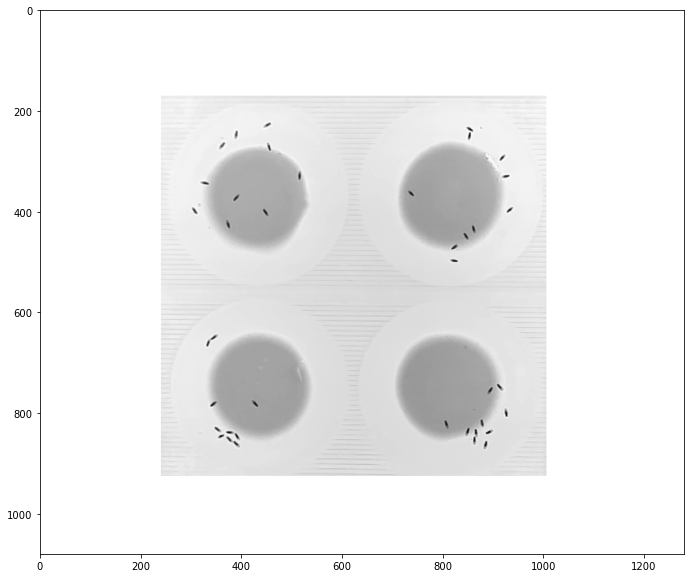

In [11]:
plt.figure(figsize=(15, 10))
plt.imshow(image, cmap='gray')

In [12]:
import cv2

In [15]:
dataset.reader.get(cv2.CAP_PROP_POS_FRAMES)

0.0

In [16]:
print("Running tracker.")
df = run(movie_path, mask, n_arenas=4, mapping_folder=mapping_folder, gpu=True)

Running tracker.
Done with frame 0
Done with frame 1000
Done with frame 2000
Done with frame 3000
Done with frame 4000
Done with frame 5000
Done with frame 6000
Done with frame 7000
Done with frame 8000
Done with frame 9000
Done with frame 10000
Done with frame 11000
Done with frame 12000
Done with frame 13000
Done with frame 14000
Done with frame 15000
Done with frame 16000
Done with frame 17000
Done with frame 18000
Done with frame 19000
Done with frame 20000
Done with frame 21000
Done with frame 22000
Done with frame 23000
Done with frame 24000
Done with frame 25000
Done with frame 26000
Done with frame 27000
Done with frame 28000
Done with frame 29000
Done with frame 30000
Done with frame 31000
Done with frame 32000
Done with frame 33000
Done with frame 34000
Done with frame 35000
Done with frame 36000
Done with frame 37000
Done with frame 38000
Done with frame 39000
Done with frame 40000
Done with frame 41000
Done with frame 42000
Done with frame 43000
Done with frame 44000
Done w

In [17]:
# Saving
df.to_hdf("results/df.hdf", key="df", complevel=9, complib="blosc")

In [18]:
output_loc = "videos/annotated_video.mp4"
print("Started annotating.")
annotate(
    df, movie_path, mapping_folder, output_loc, track_length=20, touching_distance=10,
)


Started annotating.
Done with frame 1000
Done with frame 2000
Done with frame 3000
Done with frame 4000
Done with frame 5000
Done with frame 6000
Done with frame 7000
Done with frame 8000
Done with frame 9000
Done with frame 10000
Done with frame 11000
Done with frame 12000
Done with frame 13000
Done with frame 14000
Done with frame 15000
Done with frame 16000
Done with frame 17000
Done with frame 18000
Done with frame 19000
Done with frame 20000
Done with frame 21000
Done with frame 22000
Done with frame 23000
Done with frame 24000
Done with frame 25000
Done with frame 26000
Done with frame 27000
Done with frame 28000
Done with frame 29000
Done with frame 30000
Done with frame 31000
Done with frame 32000
Done with frame 33000
Done with frame 34000
Done with frame 35000
Done with frame 36000
Done with frame 37000
Done with frame 38000
Done with frame 39000
Done with frame 40000
Done with frame 41000
Done with frame 42000
Done with frame 43000
Done with frame 44000
Done with frame 45000